In [1]:
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt
import time
import cv2

In [2]:
target_path = "./images/ball.jpg"
source_path = "./images/water.jpg"
mask_path = "./images/mask.png"

target_path = "./images/corrupted.jpg"
source_path = "./images/ball.jpg"
mask_path = "./images/corrupted_mask.png"

target = cv2.imread(target_path)
source = cv2.imread(source_path)
mask = cv2.imread(mask_path)

# source = cv2.resize(source, (300, 300))

size = source.shape[:2][::-1]
target = cv2.resize(target, size)
mask = cv2.resize(mask, size)

target = cv2.cvtColor(target, cv2.COLOR_BGR2RGB)
source = cv2.cvtColor(source, cv2.COLOR_BGR2RGB)
mask = cv2.cvtColor(mask, cv2.COLOR_BGR2GRAY)

if "water" in source_path:
    target_source = (source, target)
else:
    target_source = (target, source)

u - градієнт зображення
$$ J(u_x, u_y, u) = \sum_{i=mask_{hmin}}^{mask_{hmax}} \left(\sum_{j=mask_{wmin}}^{mask_{wmin}}\left( \left(u_x(i, j) - v_x(i, j)\right)^2 + \left(u_y(i, j) - v_y(i, j)\right)^2 \right)\right) \rightarrow min $$
$u_{xx}$ - градієнтре поле по х
$$ \frac{\partial{}}{\partial{x}} (2(u_{x} - v_{x})) = 2(u_{xx} - v_{xx}) $$
$$ \frac{\partial{}}{\partial{y}} (2(u_{y} - v_{y})) = 2(u_{yy} - v_{yy}) $$
$$ u_{xx} + u_{yy} = v_{xx} + v_{yy} $$
$$ \Delta{u} = f $$

$$ u_{xx}(i, j) \approx u(i+1,j)−2u(i,j)+u(i−1,j) $$
$$ u_{yy}(i, j) \approx u(i,j+1)−2u(i,j)+u(i,j−1) $$
$$ \Delta{u(i, j)} \approx u(i+1,j)​+u(i−1,j)​+u(i,j+1)​+u(i,j−1)​−4u(i,j)​ $$

In [3]:
def poisson_seidel(target, source, mask, iterations=2000):
    _target = target.astype(np.float64)
    _source = source.astype(np.float64)
    _mask = mask.astype(bool)
    _mask = _mask[:, :, None]

    kernel_laplacian = np.array([
        [0, 1, 0],
        [1, -4, 1],
        [0, 1, 0]],
        dtype=np.float64
    )
    laplacian = cv2.filter2D(_source, -1, kernel_laplacian)

    kernel_neighbours = np.array([
        [0, 1, 0],
        [1, 0, 1],
        [0, 1, 0]],
        dtype=np.float64
    )
    for _ in range(iterations):
        sum_neighbours = cv2.filter2D(_target, -1, kernel_neighbours)

        new_target = 1/4 * (sum_neighbours - laplacian)

        _target = _target * ~_mask + new_target * _mask

    return np.clip(_target, 0, 255).astype(np.uint8)


# res_seidel = poisson_seidel(*target_source, mask, iterations=500)
# plt.figure(figsize=(8, 8))
# plt.subplot(221), plt.imshow(target.astype('uint8')), plt.title("Target"), plt.axis('off')
# plt.subplot(222), plt.imshow(source.astype('uint8')), plt.title("Source"), plt.axis('off')
# plt.subplot(223), plt.imshow(mask, cmap='gray'), plt.title("Mask"), plt.axis('off')
# plt.subplot(224), plt.imshow(res_seidel), plt.title("Result (Seidel)"), plt.axis('off')
# plt.show()


\begin{equation}
    \mathbf{A}\mathbf{x} = \mathbf{b},
\end{equation}

A - розріджена матриця  
\begin{equation}
    A(i, j) = 
    \begin{cases} 
        -4, & \text{діагональний елемент} \\
        1, & \text{сусід всередині маски}\\
        0, & \text{інші випадки}
    \end{cases}
\end{equation}

b - градієнти джерела + граничні умови  
\begin{equation}
    b_i = f_i - \sum_{k} T_k,
\end{equation}

x - обрані пікселі маски

In [4]:
def poisson_scipy(target, source, mask):
    _target = target.astype(np.float64)
    _source = source.astype(np.float64)
    _mask = mask.astype(bool)
    
    mask_inner = np.zeros_like(_mask)
    mask_inner[1:-1, 1:-1] = _mask[1:-1, 1:-1]

    i_range, j_range = np.where(mask_inner)
    num_pixels = len(i_range)

    coord_to_index = -np.ones(_mask.shape, dtype=int)
    coord_to_index[i_range, j_range] = np.arange(num_pixels)
    
    kernel_laplacian = np.array([
        [0, 1, 0],
        [1, -4, 1],
        [0, 1, 0]],
        dtype=np.float64
    )
    laplacian = cv2.filter2D(_source, -1, kernel_laplacian)
    b = laplacian[i_range, j_range]

    rows = [np.arange(num_pixels)]
    cols = [np.arange(num_pixels)]
    data = [np.full(num_pixels, -4, dtype=np.float64)]


    neighbors = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    for di, dj in neighbors:
        ni, nj = i_range + di, j_range + dj
        
        is_inner = mask_inner[ni, nj]
        
        valid_idx = is_inner.nonzero()[0]
        if len(valid_idx) > 0:
            rows.append(valid_idx)
            cols.append(coord_to_index[ni[valid_idx], nj[valid_idx]])
            data.append(np.full(len(valid_idx), 1, dtype=np.float64))

        boundary_idx = (~is_inner).nonzero()[0]
        if len(boundary_idx) > 0:
            b[boundary_idx] -= _target[ni[boundary_idx], nj[boundary_idx]]

    _rows = np.concatenate(rows)
    _cols = np.concatenate(cols)
    _data = np.concatenate(data)

    A = sp.coo_matrix((_data, (_rows, _cols)), shape=(num_pixels, num_pixels))
    A_csr = A.tocsr()
    # print(A_csr)
    x_solution = sp.linalg.spsolve(A_csr, b)
    _target[i_range, j_range] = np.clip(x_solution, 0, 255)

    return _target.astype(np.uint8)

# res_scipy = poisson_scipy(*target_source, mask)
# plt.figure(figsize=(8, 8))
# plt.subplot(221), plt.imshow(target.astype('uint8')), plt.title("Target"), plt.axis('off')
# plt.subplot(222), plt.imshow(source.astype('uint8')), plt.title("Source"), plt.axis('off')
# plt.subplot(223), plt.imshow(mask, cmap='gray'), plt.title("Mask"), plt.axis('off')
# plt.subplot(224), plt.imshow(res_scipy), plt.title("Result (Scipy)"), plt.axis('off')
# plt.show()

Seidel Time (sec)    | SciPy Time (sec)    
---------------------------------------------
7.1044               | 0.4079              


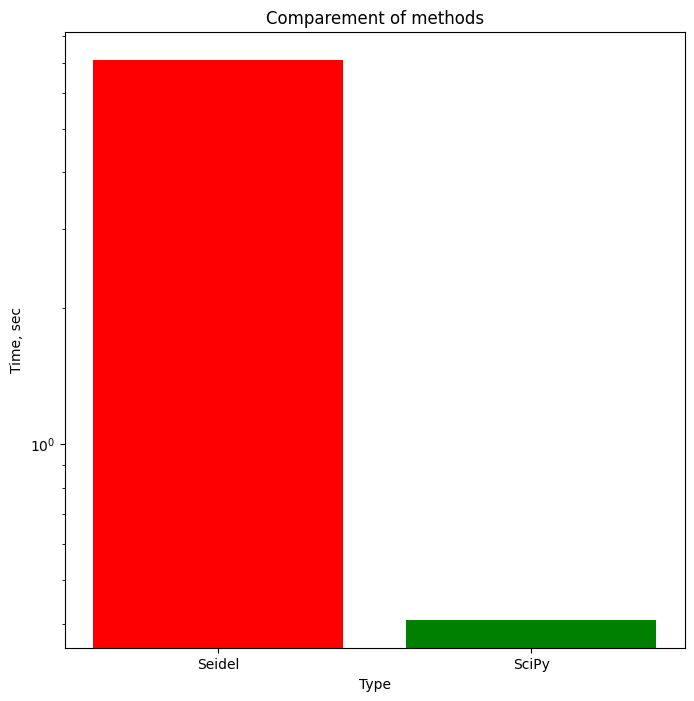

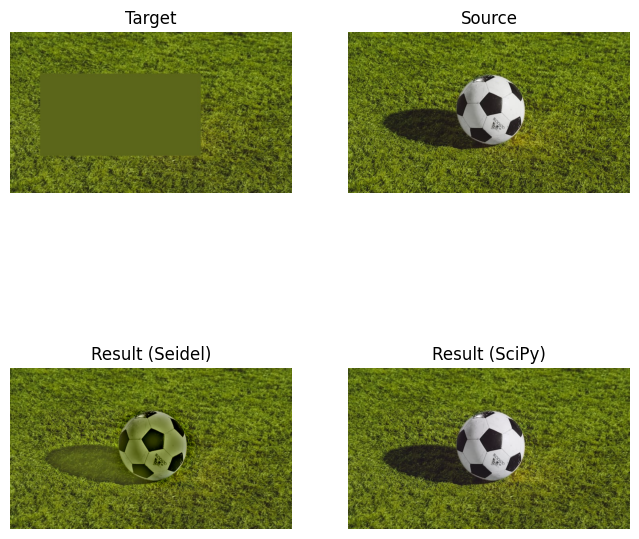

In [5]:
print(f"{'Seidel Time (sec)':<20} | {'SciPy Time (sec)':<20}")
print("-" * 45)

start = time.time()
iterations = 500
res_seidel = poisson_seidel(*target_source, mask, iterations=iterations)
end = time.time()
t_seidel = end - start

start = time.time()
res_scipy = poisson_scipy(*target_source, mask)
end = time.time()
t_scipy = end - start

print(f"{str(round(t_seidel, 4)):<20} | {str(round(t_scipy, 4)):<20}")

plt.figure(figsize=(8, 8))
plt.bar("Seidel", t_seidel, color='red')
plt.bar("SciPy", t_scipy, color='green')

plt.title('Comparement of methods')
plt.xlabel('Type')
plt.ylabel('Time, sec')
plt.yscale('log')

plt.figure(figsize=(8, 8))
plt.subplot(221), plt.imshow(target.astype('uint8')), plt.title("Target"), plt.axis('off')
plt.subplot(222), plt.imshow(source.astype('uint8')), plt.title("Source"), plt.axis('off')
plt.subplot(223), plt.imshow(res_seidel), plt.title("Result (Seidel)"), plt.axis('off')
plt.subplot(224), plt.imshow(res_scipy), plt.title("Result (SciPy)"), plt.axis('off')
plt.show()